In [1]:
import os
os.environ['TF_CP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
from matplotlib.image import imread
import requests
import matplotlib.pyplot as plt
import matplotlib
import tensorflow as tf
matplotlib.rcParams['figure.figsize'] = (9, 6)

2026-06-13 09:47:04.196500: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Text(0.5, 1.0, 'Bar graph of singular value')

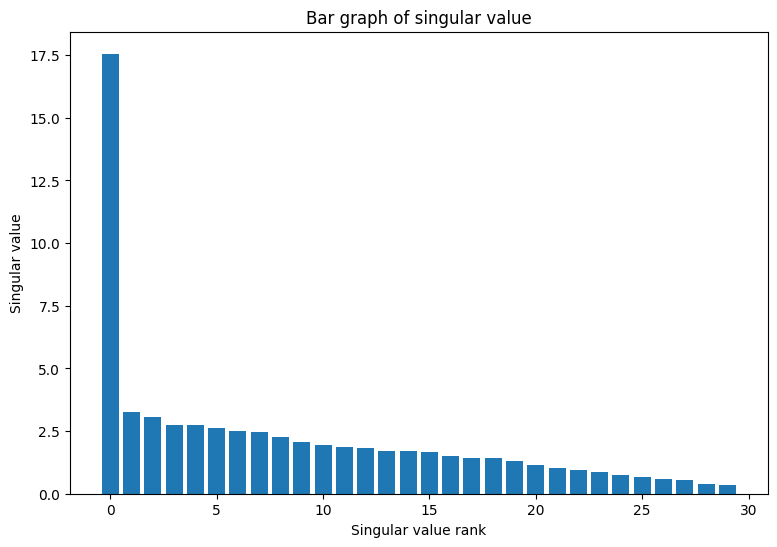

In [2]:
A = tf.random.uniform(shape=[40, 30], dtype=tf.float32)
s, U, V = tf.linalg.svd(A)
S = tf.linalg.diag(s)
V_T = tf.transpose(V)
A_svd = U @ S @ V_T
plt.bar(range(len(s)), s)
plt.xlabel('Singular value rank')
plt.ylabel('Singular value')
plt.title('Bar graph of singular value')

In [3]:
A_svd = tf.einsum('s, us, vs -> uv', s, U, V)
print('\nReconstructed Matrix, A_svd', A_svd)


Reconstructed Matrix, A_svd tf.Tensor(
[[0.3379752  0.9488956  0.11303604 ... 0.7355498  0.5770204  0.05182863]
 [0.59885484 0.19762653 0.24473302 ... 0.11922731 0.10833323 0.5738766 ]
 [0.6368197  0.10690226 0.87355816 ... 0.4619196  0.63938993 0.76004916]
 ...
 [0.69174266 0.99661016 0.05846256 ... 0.71389604 0.284971   0.91477555]
 [0.76157886 0.998417   0.89424485 ... 0.85601383 0.79878426 0.11899674]
 [0.8219627  0.9266916  0.10942633 ... 0.5676611  0.57199967 0.8233664 ]], shape=(40, 30), dtype=float32)


In [4]:
def rank_r_approx(s, U, V, r, verbose=False):
    s_r, U_r, V_r = s[..., :r], U[..., :, :r], V[..., :, :r]
    A_r = tf.einsum('...s, ...us, ...vs -> ...uv', s_r, U_r, V_r)
    A_r_size = tf.size(U_r) + tf.size(s_r) + tf.size(V_r)
    if verbose:
        print(f'Approximation size: {A_r_size}')
    return A_r, A_r_size


def viz_approx(A, A_r):
    vmin, vmax = 0, tf.reduce_max(A)
    fig, ax = plt.subplots(1, 3)
    mats = [A, A_r, abs(A - A_r)]
    titles = ['Original A', 'Approximated A_r', 'Error |A - A_r|']
    for i, (mat, title) in enumerate(zip(mats, titles)):
        ax[i].pcolormesh(mat, vmin=vmin, vmax=vmax)
        ax[i].set_title(title)
        ax[i].axis('off')

In [5]:
print(f"Original size of A: {tf.size(A)}")
s, U, V = tf.linalg.svd(A)

Original size of A: 1200


Approximation size: 1065


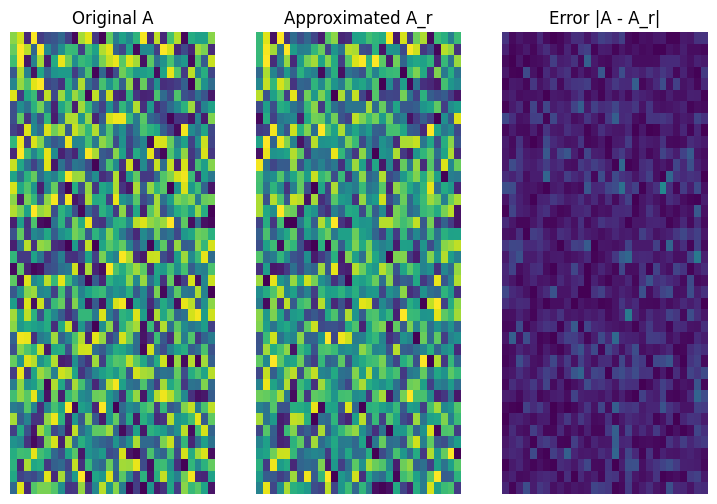

In [6]:
A_15, A_15_size = rank_r_approx(s, U, V, 15, verbose=True)
viz_approx(A, A_15)

Approximation size: 213


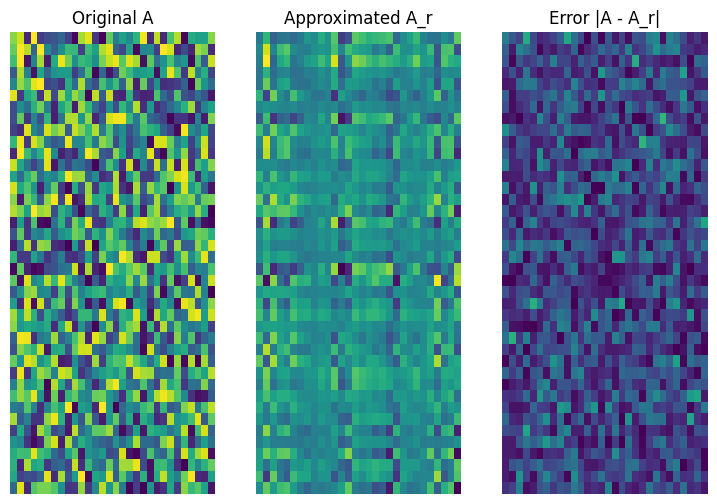

In [7]:
A_3, A_3_size = rank_r_approx(s, U, V, 3, verbose=True)
viz_approx(A, A_3)

In [8]:
img_link = "https://imagen.research.google/main_gallery_images/a-photo-of-a-corgi-dog-riding-a-bike-in-times-square.jpg"
img_path = requests.get(img_link, stream=True).raw
I = imread(img_path, 0)
print("Input Image Shape:", I.shape)

Input Image Shape: (1024, 1024, 3)


In [9]:
def show_img(I):
    img = plt.imshow(I)
    plt.axis('off')
    return

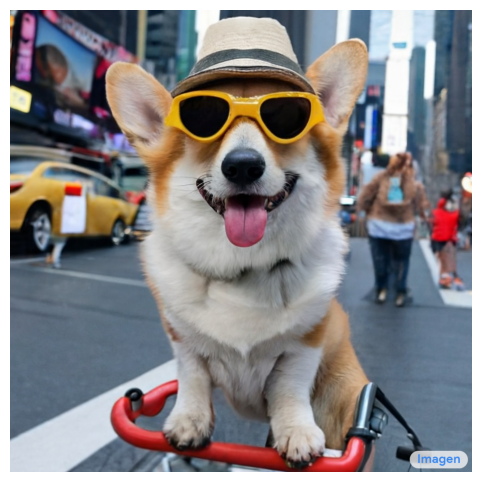

In [10]:
show_img(I)

In [11]:
def compress_image(I, r, verbose=False):
    I_size = tf.size(I)
    I = tf.convert_to_tensor(I) / 255
    I_batched = tf.transpose(I, [2, 0, 1])
    s, U, V = tf.linalg.svd(I_batched)
    I_r, I_r_size = rank_r_approx(s, U, V, r)
    I_r = tf.transpose(I_r, [1, 2, 0])
    I_r_prop = (I_r_size / I_size)
    if verbose:
        print(f"Number of singular values used in compression: {r}")
        print(f"Compressed image size: {I_r_size}")
        print(f"Poporition of original image size: {I_r_prop:.3f}")
        ax_1 = plt.subplot(1, 2, 1)
        show_img(tf.clip_by_value(I_r, 0., 1.))
        ax_1.set_title("Approximated Image")
        ax_2 = plt.subplot(1, 2, 2)
        show_img(tf.clip_by_value(0.5 + abs(I - I_r), 0., 1.))
        ax_2.set_title("Error")
    return I_r, I_r_prop

Number of singular values used in compression: 100
Compressed image size: 614700
Poporition of original image size: 0.195


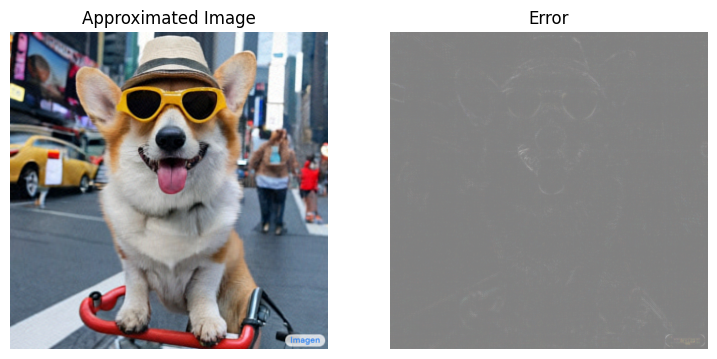

In [12]:
I_100, I_100_prop = compress_image(I, 100, verbose=True)

Number of singular values used in compression: 50
Compressed image size: 307350
Poporition of original image size: 0.098


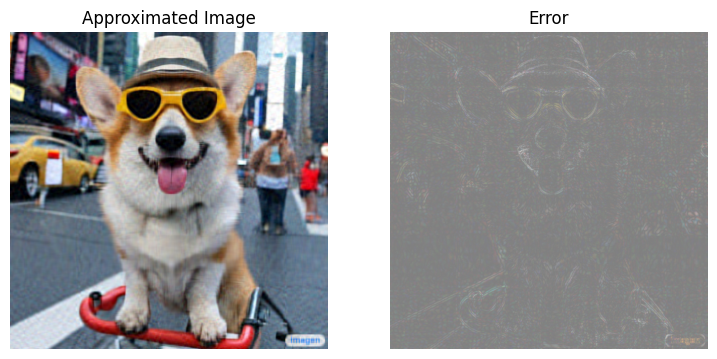

In [13]:
I_50, I_50_prop = compress_image(I, 50, verbose=True)

Number of singular values used in compression: 10
Compressed image size: 61470
Poporition of original image size: 0.020


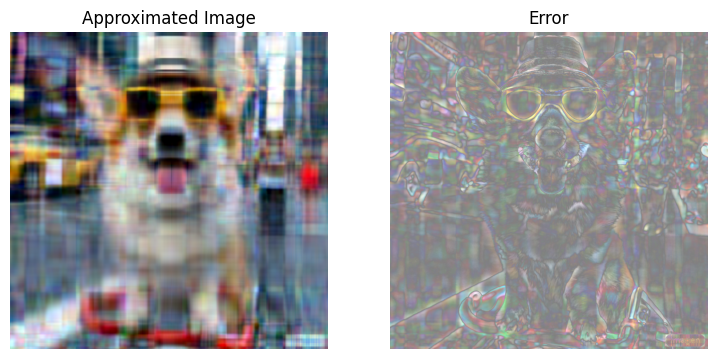

In [14]:
I_10, I_10_prop = compress_image(I, 10, verbose=True)

Text(0.5, 1.0, 'Compression factor vs rank')

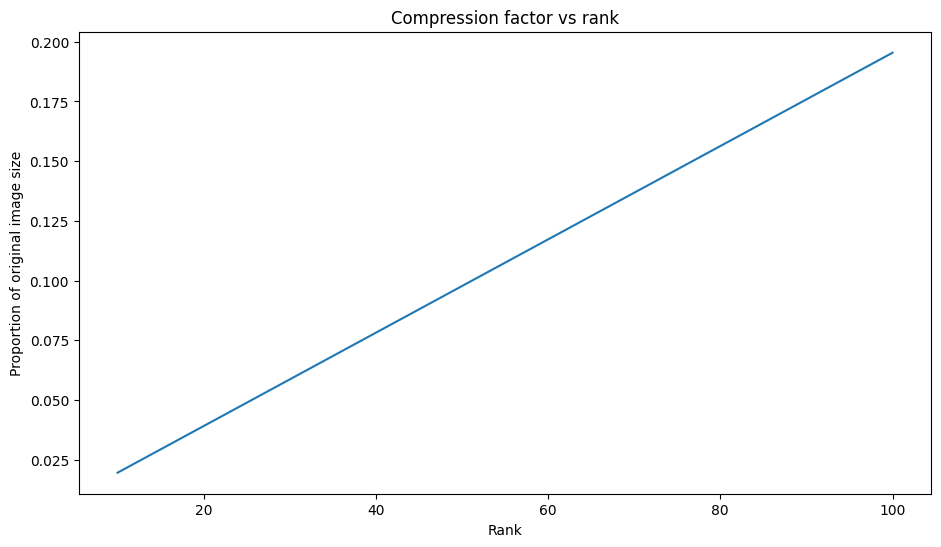

In [15]:
plt.figure(figsize=(11,6))
plt.plot([100, 50, 10], [I_100_prop, I_50_prop, I_10_prop])
plt.xlabel("Rank")
plt.ylabel("Proportion of original image size")
plt.title("Compression factor vs rank")

In [16]:
def compress_image_with_factor(I, compression_factor, verbose=False):
    m, n, o = I.shape
    r = int((compression_factor * m * n) / (m + n + 1))
    I_r, I_r_prop = compress_image(I, r, verbose=verbose)
    return I_r

Number of singular values used in compression: 76
Compressed image size: 467172
Poporition of original image size: 0.149


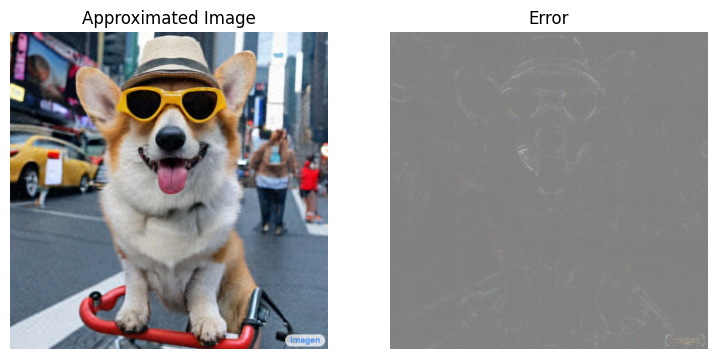

In [17]:
compression_factor = 0.15
I_r_img = compress_image_with_factor(I, compression_factor, verbose=True)

In [18]:
def viz_energy(I):
    I = tf.convert_to_tensor(I) / 255
    I_batched = tf.transpose(I, [2, 0, 1])
    s, U, V = tf.linalg.svd(I_batched)
    props_rgb = tf.map_fn(lambda x: tf.cumsum(x) / tf.reduce_sum(x), s)
    props_rgb_mean = tf.reduce_mean(props_rgb, axis=0)
    plt.figure(figsize=(11, 6))
    plt.plot(range(len(I)), props_rgb_mean, color='k')
    plt.xlabel("Rank / singular value number")
    plt.ylabel("Cumulative proportion of singular values")
    plt.title("RGB-averaged proportion of energy captured by the first r singular values")

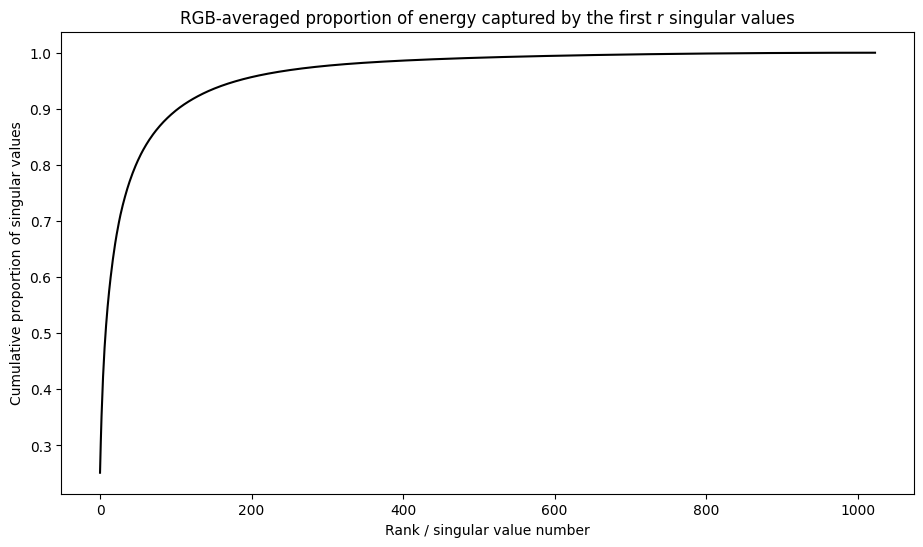

In [19]:
viz_energy(I)

In [20]:
def compress_image_with_energy(I, energy_factor, verbose=False):
    I_rescaled = tf.convert_to_tensor(I) / 255
    I_batched = tf.transpose(I_rescaled, [2, 0, 1])
    s, U, V = tf.linalg.svd(I_batched)
    props_rgb = tf.map_fn(lambda x: tf.cumsum(x) / tf.reduce_sum(x), s)
    props_rgb_mean = tf.reduce_mean(props_rgb, axis=0)
    r = tf.argmin(tf.abs(props_rgb_mean - energy_factor)) + 1
    actual_ef = props_rgb_mean[r]
    I_r, I_r_prop = compress_image(I, r, verbose=verbose)
    print(f"Proportion of energy captured by the first {r} singular values: {actual_ef} ")
    return I_r

Number of singular values used in compression: 35
Compressed image size: 215145
Poporition of original image size: 0.068
Proportion of energy captured by the first 35 singular values: 0.7530428767204285 


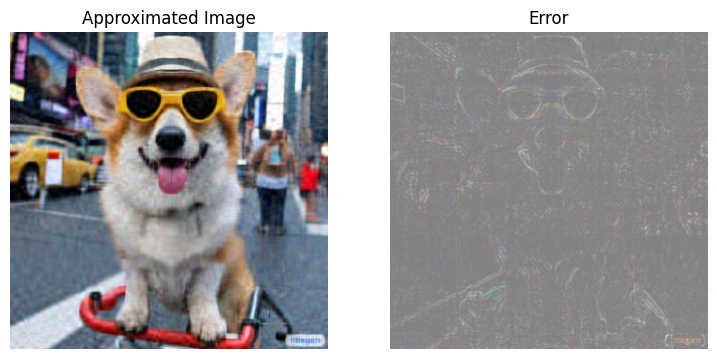

In [21]:
energy_factor = 0.75
I_r_img = compress_image_with_energy(I, energy_factor, verbose=True)

In [22]:
s, U, V = tf.linalg.svd(A)
A_10, A_10_size = rank_r_approx(s, U, V, 10)
squared_norm = tf.norm(A - A_10)**2
s_squared_sum = tf.reduce_sum(s[10:]**2)
print(f"Squared Frobenius norm: {squared_norm:.3f}")
print(f"Sum of squared singular values left out: {s_squared_sum:.3f}")

Squared Frobenius norm: 33.230
Sum of squared singular values left out: 33.230
